# Domača naloga 2



## Naloga 1: Izbira modelov

##### 1.a: Spodnja slika prikazuje odločitvene krivulje (odločitvene meje) štirih modelov na isti podatkovni množici za binarno klasifikacijo z $D_Y = \{0, 1\}$. Krivulje so podane kot graf verjetnosti za vrednost ciljne spremenljivke 1, $P(Y=1)$. Za vsako sliko:

1. Identificiraj, kateri model (izmed tistih, ki smo jih delali na vajah in so lahko nelinearni brez spreminjanja podatkov) je ustvaril to odločitveno krivuljo.
2. Razloži, zakaj je ta odločitvena krivulja značilna za ta model.
3. Predlagaj vsaj eno konkretno spremembo, ki bi model naredila bolj točen na testnih podatkih in/ali bolj stabilen.
4. Razloži, kako bi spremembe vplivale na odločitveno krivuljo.

![Odločitvene krivulje modelov](1a_modeli.png)

**Odgovor**:

- Model A:
    - Ime modela: KNN (najverjetneje z majhnim `k`, npr. `k=1`)
    - Zakaj si model izbral: Meja je zelo nelinearna in lokalno "razcefrana" z majhnimi otočki. To je tipično za KNN, ko napoved močno določajo najbližji posamezni primeri.
    - Kako bi ga izboljšal: Povečal bi vrednost parametra `k`(število upoštevanih sosedov).
    - Kako bi to vplivalo na krivuljo: Meja bi bila bolj gladka in manj občutljiva na šum. Manj bi bilo majhnih otočkov in model bi bil stabilnejši na testu.

- Model B:
    - Ime modela: Naključni gozd (`RandomForest`)
    - Zakaj si model izbral: Meje so sestavljene iz pravokotnih na osi poravnanih rezi. Podobno kot pri posameznem odločitvenem drevesu, vendar je prisotnih več različnih nivojev verjetnosti (različni odtenki rdeče/bele). To pomeni, da je končna napoved povprečje napovedi več različnih dreves, kar zgladi meje v stopničaste prehode zveznih verjetnosti.
    - Kako bi ga izboljšal: Povečal bi `n_estimators`, omejil globino (`max_depth`) in povečal `min_samples_leaf` za manjšo varianco.
    - Kako bi to vplivalo na krivuljo: Prehodi bi bili bolj stabilni in manj nazobčani. Model ne bi več tako natančno sledil posameznim točkam.

- Model C:
    - Ime modela: Odločitveno drevo (`DecisionTree`)
    - Zakaj si model izbral: Odločitvene meje so ostro pravokotne in po osi poravnane. Prehodi so ostri in fiksni (verjetnost je strogo 0 ali 1, brez vmesnih senčenj), kar je značilno za eno samo drevo.
    - Kako bi ga izboljšal: Uvedel bi rezanje/regularizacijo (`max_depth`, `min_samples_leaf`, `ccp_alpha`).
    - Kako bi to vplivalo na krivuljo: Število pravokotnih rezi bi se močno zmanjšalo. Meja bi postala enostavnejša, sestavljena iz le nekaj glavnih pravokotnih regij, ki ločujejo glavni masi podatkov.

- Model D:
    - Ime modela: Logistična regresija (možno tudi: linearni SVM s kalibracijo verjetnosti)
    - Zakaj si model izbral: Meja je skoraj linearna, verjetnost pa se gladko spreminja čez prostor. To je najbolj značilno za logistično regresijo, vendar bi podoben vzorec lahko dobili tudi z linearnim SVM, če izhod pretvorimo v kalibrirane verjetnosti.
    - Kako bi ga izboljšal: Če ostane logistična regresija, bi dodal nelinearne/interakcijske značilke in prilagodil regularizacijo (`C`). Če gre za linearni SVM, bi testiral nelinearno jedro (RBF) ter nastavitve `C` in `gamma`.
    - Kako bi to vplivalo na krivuljo: Pri linearnem modelu bi krivulja ostala skoraj ravna, a bolj stabilna. Z nelinearnimi značilkami ali RBF jedrom bi meja postala bolj ukrivljena in bi bolje sledila strukturi podatkov.

##### 1.b: Podani so štirje scenariji. Za vsak scenarij predlagaj, kako bi predlagani pristop izboljšal. Navedi konkretno spremembo in pojasni, zakaj bi ta sprememba pomagala. Odgovor zapiši kot komentar pod vsakim scenarijem.

Scenarij A: Ekipa podatkovnih inženirjev v finančnem podjetju je razvila model podpornih vektorjev (SVM) z linearnim jedrom za odkrivanje goljufivih bančnih transakcij. Podatki vsebujejo 500.000 transakcij (s podatki: id transakcije, čas transakcije, znesek transakcije, diskretna spremenljivka namen, podatki prejemnika, podatki pošiljatelja, ...), od katerih je le nekaj označenih za goljufive. Model je po treniranju dosegel skoraj popolno točnost na testnih podatkih, kar je ekipi dalo občutek, da je model izjemno uspešen. Po namestitvi v produkcijo so stranke začele poročati, da goljufive transakcije niso bile zaznane.

- Kaj je problem: Gre za izrazito neuravnoteženost razredov. Ker je goljufivih transakcij zelo malo, lahko model preprosto napove, da je vsaka transakcija "veljavna" in s tem doseže 99.9% točnost, čeprav v praksi ne opravlja svoje naloge. Točnost (`accuracy`) je v tem primeru povsem zavajajoča metrika.
- Kako bi ga popravil: Najprej bi spremenil metriko ocenjevanja. Namesto točnosti bi uporabil metriko, ki kaznuje zgrešene goljufije, kot so priklic (`recall`), natančnost (`precision`), `F1-mera`, ali `ROC-AUC` ali `PR-AUC`. Prav tako bi morali primerno utežiti podatke. Na primer z uteževanjem razredov (v SVM nastavitev penalizacije tako, da so napake pri manjšinskem razredu dražje) ali z uporabo tehnik za uravnoteženje vzorcev (npr. SMOTE ali podvzorčenje večinskega razreda).

Scenarij B: Podjetje za nepremičnine želi napovedovati vrednosti stanovanj s pomočjo modela KNN ($k=5$). Model temelji na različnih lastnostih stanovanj (ki igrajo vlogo napovednih spremenljivk): število sob, površina v kvadratnih metrih, oddaljenost od centra mesta v minutah hoje, leto izgradnje, ... Kljub temu, da so podatki kakovostni, model dosega le skromne rezultate. Ekipa je preizkusila različne vrednosti $k$ od 1 do 30, a bistvenih izboljšav ni bilo.

- Kaj je problem: Model KNN izračunava razdalje (npr. evklidsko) med primeri, da bi našel najbližje sosede. V tem primeru imajo napovedne spremenljivke popolnoma različne skale (leto izgradnje je v tisočih, površina v stotinah, število sob pa od 1 do 10). Zaradi tega bodo spremenljivke z večjimi številskimi vrednostmi (npr. leto ali površina) povsem prevladale pri izračunu razdalje, vpliv manjših (npr. števila sob) pa bo zanemarljiv.
- Kako bi ga popravil: Preden podatke podamo modelu KNN, je nujno potrebno izvesti skaliranje (normalizacijo ali standardizacijo) vseh napovednih spremenljivk. Z uporabo npr. standardizacije (`Z-vrednosti`) bodo imele vse spremenljivke povprečje 0 in varianco 1, kar bo omogočilo, da bodo vse lastnosti enakovredno prispevale k izračunu razdalje. 

Scenarij C: Ekipa želi za napoved cene rabljenih avtomobilov izbrati najboljši model izmed petih kandidatov: linearne regresije, polinomskih regresij stopenj 2, 3 in 4 ter naključnega gozda. Na voljo imajo 400 primerov, ki jih razdelijo na 320 učnih in 80 testnih. Za vsakega kandidata izmerijo napako na testni množici in izberejo model z najnižjo izmerjeno napako — polinomsko regresijo stopnje 3 — ter napovejo, da bo ta model v produkciji dosegal enako napako. Njihov kolega opozori, da bo dejanska napaka v produkciji verjetno višja, a ekipa ne razume zakaj.

- Kaj je problem: Ekipa je uporabila testno množico za izbiro najboljšega modela. Ker so izbrali tisti model, ki se je najbolje odrezal prav na tej specifični testni množici, je ta napaka pristranska in preveč optimistična ocena za napake v produkciji (gre za t.i. uhajanje informacij oz. data leakage v fazi evalvacije).
- Kako bi ga popravil: Podatke bi razdelil na učno, validacijsko in testno množico. Model bi učil na učni množici, najboljši model izbral na podlagi napake na validacijski množici, testno množico pa bi uporabil samo enkrat na koncu za končno oceno. Testna množica ostane popolnoma neodvisna, zato napaka na njej predstavlja nepristransko oceno uspešnosti v produkciji. Druga možnost bi bila, da bi na učni množici uporabil `k-fold cross-validation` za izbiro najboljšega modela. Cross-validation omogoča, da model večkrat treniramo in validiramo na različnih delih podatkov, zato dobimo bolj stabilno in zanesljivo oceno napake.

Scenarij D: Analitiki v zavarovalnici so zgradili model za napoved verjetnosti prometne nesreče voznika v naslednjem letu, pri čemer je ciljna spremenljivka binarna (nesreča / ni nesreče). Podatki za napovedne spremenljivke so sestavljeni iz starosti voznika, povprečnega števila prevoženih kilometrov v zadnjih letih, avta, ki ga vozi, ... Za napovedovanje verjetnosti nesreče so uporabili linearno regresijo, naučeno na 50.000 primerih. Čeprav model dosega boljše rezultate kot prejšnji poskus, je pravna služba uporabo modela ustavila, saj ne zaupa napovedim, ki jih model vrača.

- Kaj je problem: Uporabljena je linearna regresija za binarni problem, kar pomeni, da model lahko napoveduje vrednosti izven intervala [0,1], kar ni smiselno za verjetnosti. Zato pravna služba ne zaupa rezultatom.
- Kako bi ga popravil: Namesto linearne regresije bi uporabil logistično regresijo. Logistična regresija uporabi sigmoidno funkcijo, ki zagotovi, da so vse izhodne vrednosti modela vedno preslikane in zamejene na interval med 0 in 1, kar predstavlja veljavne verjetnosti.

## Naloga 2: Vrečenje z naključnimi podprostori

V tej nalogi boš implementiral metodo vrečenja (angl. _bagging, bootstrap aggregating_) za klasifikacijo brez uporabe vgrajene sklearn funkcije. Vrečenje trenira več enakih modelov na različnih vzorcih učnih podatkov in njihove napovedi združi z večinskim glasovanjem.

Podatki so iz podatkovne množice **Breast Cancer Wisconsin**, ki vsebuje 569 primerov, **30 napovednih spremenljivk** (pridobljenih iz slik celic tumorja) in 2 vrednosti ciljne spremenljivke (maligni / benigni tumor). Napovednih spremenljivk je (glede na število primerov) veliko in so organizirane v korelirane trojice (povprečje, standardna napaka in najslabša vrednost za vsako od 10 mer).

Najprej naložimo podatke.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt

In [4]:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feature_names = list(bc.feature_names)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42
)
print(f"Učna množica: {X_w_train.shape[0]} primerov | Testna množica: {X_w_test.shape[0]} primerov")
print(f"Lastnosti ({len(feature_names)}): {feature_names}\n")

Učna množica: 398 primerov | Testna množica: 171 primerov
Lastnosti (30): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]



##### 2.a: Vzorčenje s ponavljanjem (angl. _bootstrap sampling_)

Implementiraj funkcijo `vzorci_z_vracanjem(X, y)`, ki vrne vzorec _bootstrap_ s ponavljanjem: naključno izbran vzorec iste velikosti kot vhodna podatkovna množica, pri katerem se isti primer se lahko pojavi večkrat; nekateri primeri morda sploh ne.

In [17]:
def vzorci_z_vracanjem(X: np.ndarray, y: np.ndarray):
    """Vrne bootstrap vzorec (vzorčenje z vračanjem) iste velikosti kot vhodni podatki."""
    n_primerov = X.shape[0]
    indeksi = np.random.choice(n_primerov, size=n_primerov, replace=True)
    return X[indeksi], y[indeksi]


X_vzorec, y_vzorec = vzorci_z_vracanjem(X_w_train, y_w_train)
assert X_vzorec.shape == X_w_train.shape, f"Napačna oblika: {X_vzorec.shape}"
assert y_vzorec.shape == y_w_train.shape
print(f"Vzorec bootstrap: {X_vzorec.shape[0]} primerov. "
      f"Pričakovano ~{int(X_w_train.shape[0] * 0.632)} edinstvenih. "
      f"Dobljeno: {np.unique(X_vzorec, axis=0).shape[0]} edinstvenih")


Vzorec bootstrap: 398 primerov. Pričakovano ~251 edinstvenih. Dobljeno: 247 edinstvenih


##### 2.b: Naključni podprostor napovednih spremenljivk

Implementiraj funkcijo `nakljucni_podprostor(X, n_features)`, ki naključno izbere `n_features` stolpcev (napovednih spremenljivk) iz matrike X in vrne par `(X_sub, indices)`:
- `X_sub`: matrika z izbranimi stolpci
- `indices`: indeksi izbranih stolpcev (potrebni so pri napovedovanju, da izberemo pravi podprostor iz novih podatkov)

In [10]:
def nakljucni_podprostor(X: np.ndarray, n_features: int):
    """Vrne (X_sub, indices): naključno izbrane n_features lastnosti iz X."""
    st_lastnosti = X.shape[1]
    if not 1 <= n_features <= st_lastnosti:
        raise ValueError(f"n_features mora biti med 1 in {st_lastnosti}, dobil pa sem {n_features}.")

    indices = np.random.choice(st_lastnosti, size=n_features, replace=False)
    X_sub = X[:, indices]
    return X_sub, indices


# Preverjanje
X_sub, idx_sub = nakljucni_podprostor(X_w_train, 5)
assert X_sub.shape == (X_w_train.shape[0], 5), f"Napačna oblika: {X_sub.shape}"
assert len(idx_sub) == 5
print(f"Podprostor: {X_sub.shape}, izbrani indeksi: {sorted(idx_sub.tolist())}\n")

Podprostor: (398, 5), izbrani indeksi: [13, 14, 17, 22, 24]



##### 2.c: Razred `VrecaModelov`

Implementiraj razred `VrecaModelov` (BaggingClassifier), ki gradi ansambel z vrečenjem odločitvenih dreves.

Parametri:
- `n_estimators` (int): število dreves v ansamblu,
- `max_features` (int ali None): število naključno izbranih lastnosti za vsako drevo; None pomeni, da se uporabijo vse lastnosti,
- `bootstrap` (bool): ali se primeri vzorčijo s ponavljanjem (ali brez).

Metoda `fit(X, y)`, ki za vsako drevo:
1. Vzorči primere z `vzorci_z_vracanjem` (če bootstrap=True), sicer vzemi vse.
2. Izberi naključni podprostor z `nakljucni_podprostor` (če max_features ni `None`, sicer pa vzemi vse napovedne spremenljivke).
3. Nauči `DecisionTreeClassifier` in ga shrani skupaj z indeksi izbranih napovednih spremenljivk.

Metoda `predict(X)`:
Za vsak primer v `X` zberi napovedi vseh dreves (pozor, vsako drevo naj napove na svojem podprostoru) in vrni vrednost ciljne spremenljivke, za katero je glasovala večina dreves.

Metoda `predict_proba(X)`:
Vrni matriko oblike (`n_primerov`, `n_razredov`), kjer vsaka vrstica vsebuje delež dreves, ki so glasovala za posamezen razred (vrednosti so iz intervala [0, 1] in se seštejejo v 1).


In [18]:
class VrecaModelov:
    """Ansambel odločitvenih dreves z vzorčenjem podatkov in/ali naključnim podprostorom."""

    def __init__(self, n_estimators: int = 50, max_features: int = None, bootstrap: bool = True):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.drevesa = []
        self.feature_indices = []
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        """Nauči ansambel dreves na (pod)vzorcih podatkov."""
        self.drevesa = []
        self.feature_indices = []
        self.classes_ = np.unique(y)

        n_skupnih_lastnosti = X.shape[1]
        if self.max_features is not None and not 1 <= self.max_features <= n_skupnih_lastnosti:
            raise ValueError(
                f"max_features mora biti med 1 in {n_skupnih_lastnosti}, dobil pa sem {self.max_features}."
            )

        for _ in range(self.n_estimators):
            if self.bootstrap:
                X_train, y_train = vzorci_z_vracanjem(X, y)
            else:
                X_train, y_train = X, y

            if self.max_features is None:
                idx = np.arange(n_skupnih_lastnosti)
                X_sub = X_train
            else:
                X_sub, idx = nakljucni_podprostor(X_train, self.max_features)

            drevo = DecisionTreeClassifier()
            drevo.fit(X_sub, y_train)

            self.drevesa.append(drevo)
            self.feature_indices.append(idx)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Napove razrede z večinskim glasovanjem vseh dreves."""
        if len(self.drevesa) == 0:
            raise ValueError("Model še ni naučen. Najprej pokliči fit(X, y).")

        glasovi = np.column_stack([
            drevo.predict(X[:, idx])
            for drevo, idx in zip(self.drevesa, self.feature_indices)
        ])

        stetje_glasov = np.column_stack([
            np.sum(glasovi == razred, axis=1)
            for razred in self.classes_
        ])
        return self.classes_[np.argmax(stetje_glasov, axis=1)]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Vrne verjetnosti razredov kot delež glasov; oblika (n_primerov, n_razredov)."""
        if len(self.drevesa) == 0:
            raise ValueError("Model še ni naučen. Najprej pokliči fit(X, y).")

        glasovi = np.column_stack([
            drevo.predict(X[:, idx])
            for drevo, idx in zip(self.drevesa, self.feature_indices)
        ])

        stetje_glasov = np.column_stack([
            np.sum(glasovi == razred, axis=1)
            for razred in self.classes_
        ])
        return stetje_glasov / len(self.drevesa)


# Preverjanje pravilnosti VrecaModelov
np.random.seed(42)
_vm = VrecaModelov(n_estimators=50, bootstrap=True)
_vm.fit(X_w_train, y_w_train)

_pred = _vm.predict(X_w_test)
_proba = _vm.predict_proba(X_w_test)

assert _pred.shape == (X_w_test.shape[0],), \
    f"Napačna oblika predict: {_pred.shape}"
assert _proba.shape == (X_w_test.shape[0], len(np.unique(y_bc))), \
    f"Napačna oblika predict_proba: {_proba.shape}"
assert np.allclose(_proba.sum(axis=1), 1.0), \
    "Verjetnosti v vrsticah se ne seštejejo v 1"
assert np.array_equal(_pred, _vm.classes_[_proba.argmax(axis=1)]), \
    "predict in argmax(predict_proba) se ne ujemata"

_solo = DecisionTreeClassifier(random_state=42).fit(X_w_train, y_w_train)
assert accuracy_score(y_w_test, _pred) >= accuracy_score(y_w_test, _solo.predict(X_w_test)) - 0.05, \
    "VrecaModelov bistveno slabši od enega drevesa – preverite implementacijo"

print(f"Preverjanje VrecaModelov uspešno! "
      f"Točnost: {accuracy_score(y_w_test, _pred):.4f}, "
      f"oblika verjetnosti: {_proba.shape}, "
      f"primer verjetnosti (prva vrstica): {_proba[0].round(2)}")

Preverjanje VrecaModelov uspešno! Točnost: 0.9591, oblika verjetnosti: (171, 2), primer verjetnosti (prva vrstica): [0. 1.]


##### 2.d: Primerjava konfiguracij in korelacija dreves

Primerjaj štiri konfiguracije:
1. Eno odločitveno drevo
2. VrecaModelov (bootstrap=True,  max_features=None) – samo bootstrap
3. VrecaModelov (bootstrap=False, max_features=int(sqrt(30))) – samo podprostor lastnosti
4. VrecaModelov (bootstrap=True,  max_features=int(sqrt(30))) – kombinacija bootstrap in podprostor

Za vsako konfiguracijo:
- Izračunaj točnost na učni in testni množici ter AUC.
- Za vsako konfiguracijo izračunaj povprečno Pearsonovo korelacijo napovedi med drevesi iz ansambla na testni množici.
- Nariši histogram zaupanja (maksimalna verjetnost vrednosti ciljne spremenljivke) ločeno za pravilne in napačne napovedi.

Odgovori:
- Katera konfiguracija je najboljša in zakaj?
- Kako korelacija dreves vpliva na kakovost ansambla?
- Kaj histogram zaupanja pove o tem, kdaj model naredi napako?

In [19]:
np.random.seed(42)
n_feat_sqrt = int(np.sqrt(X_bc.shape[1]))  # sqrt(30) ≈ 5


def _avg_pearson_corr_med_drevesi(model, X_test):
    """Povprecna Pearsonova korelacija napovedi med drevesi na testni mnozici."""
    # Za eno drevo korelacija med drevesi ni definirana.
    if not hasattr(model, "drevesa") or len(model.drevesa) < 2:
        return np.nan

    napovedi_dreves = np.column_stack([
        drevo.predict(X_test[:, idx])
        for drevo, idx in zip(model.drevesa, model.feature_indices)
    ]).astype(float)

    corr = np.corrcoef(napovedi_dreves, rowvar=False)
    zg_trikotnik = np.triu_indices_from(corr, k=1)
    return np.nanmean(corr[zg_trikotnik])


def _eval_in_histogram(model, ime_konfiguracije):
    """Izracuna metrike in narise histogram zaupanja za pravilne/napacne napovedi."""
    y_train_pred = model.predict(X_w_train)
    y_test_pred = model.predict(X_w_test)

    y_train_proba = model.predict_proba(X_w_train)
    y_test_proba = model.predict_proba(X_w_test)

    acc_train = accuracy_score(y_w_train, y_train_pred)
    acc_test = accuracy_score(y_w_test, y_test_pred)

    # Binarna klasifikacija: AUC racunamo na verjetnost pozitivnega razreda (stolpec 1).
    auc_train = roc_auc_score(y_w_train, y_train_proba[:, 1])
    auc_test = roc_auc_score(y_w_test, y_test_proba[:, 1])

    povp_corr = _avg_pearson_corr_med_drevesi(model, X_w_test)

    zaupanje = y_test_proba.max(axis=1)
    mask_pravilno = (y_test_pred == y_w_test)
    mask_napacno = ~mask_pravilno

    plt.figure(figsize=(8, 4))
    plt.hist(zaupanje[mask_pravilno], bins=15, alpha=0.7, label="Pravilne napovedi")
    plt.hist(zaupanje[mask_napacno], bins=15, alpha=0.7, label="Napacne napovedi")
    plt.xlabel("Maksimalna napovedana verjetnost (zaupanje)")
    plt.ylabel("Stevilo primerov")
    plt.title(f"Histogram zaupanja - {ime_konfiguracije}")
    plt.legend()
    plt.show()

    print(f"=== {ime_konfiguracije} ===")
    print(f"Tocnost (ucna): {acc_train:.4f}")
    print(f"Tocnost (testna): {acc_test:.4f}")
    print(f"AUC (ucna): {auc_train:.4f}")
    print(f"AUC (testna): {auc_test:.4f}")
    if np.isnan(povp_corr):
        print("Povprecna Pearsonova korelacija med drevesi: ni definirana (eno drevo)")
    else:
        print(f"Povprecna Pearsonova korelacija med drevesi (test): {povp_corr:.4f}")

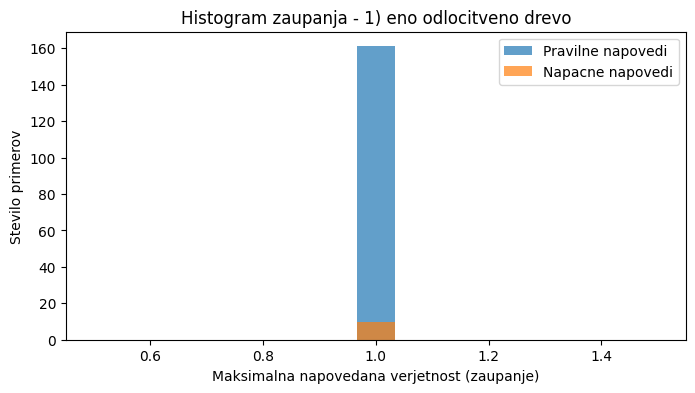

=== 1) eno odlocitveno drevo ===
Tocnost (ucna): 1.0000
Tocnost (testna): 0.9415
AUC (ucna): 1.0000
AUC (testna): 0.9438
Povprecna Pearsonova korelacija med drevesi: ni definirana (eno drevo)


In [20]:
# Konfiguracija 1: Eno odlocitveno drevo
np.random.seed(42)
model_cfg1 = DecisionTreeClassifier(random_state=42)
model_cfg1.fit(X_w_train, y_w_train)
_eval_in_histogram(model_cfg1, "1) eno odlocitveno drevo")

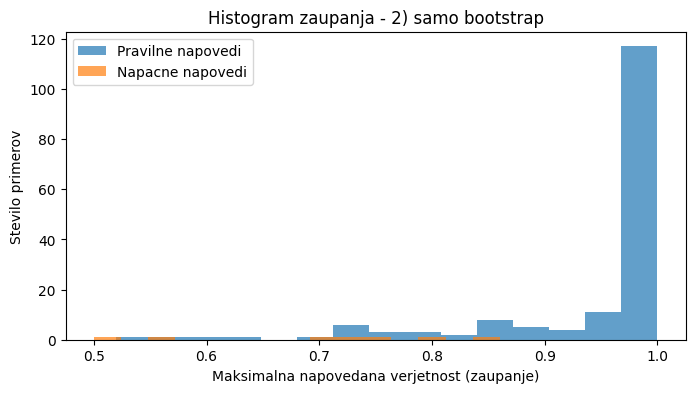

=== 2) samo bootstrap ===
Tocnost (ucna): 1.0000
Tocnost (testna): 0.9591
AUC (ucna): 1.0000
AUC (testna): 0.9929
Povprecna Pearsonova korelacija med drevesi (test): 0.8131


In [21]:
# Konfiguracija 2: VrecaModelov (bootstrap=True, max_features=None)
np.random.seed(42)
model_cfg2 = VrecaModelov(
    n_estimators=50,
    bootstrap=True,
    max_features=None
)
model_cfg2.fit(X_w_train, y_w_train)
_eval_in_histogram(model_cfg2, "2) samo bootstrap")

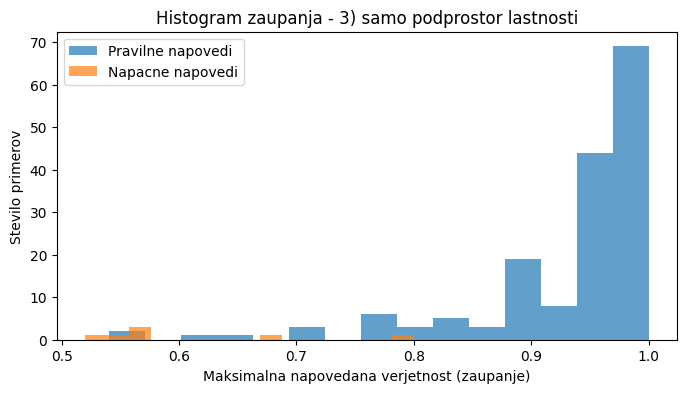

=== 3) samo podprostor lastnosti ===
Tocnost (ucna): 1.0000
Tocnost (testna): 0.9591
AUC (ucna): 1.0000
AUC (testna): 0.9967
Povprecna Pearsonova korelacija med drevesi (test): 0.7352


In [22]:
# Konfiguracija 3: VrecaModelov (bootstrap=False, max_features=int(sqrt(30)))
np.random.seed(42)
model_cfg3 = VrecaModelov(
    n_estimators=50,
    bootstrap=False,
    max_features=n_feat_sqrt
)
model_cfg3.fit(X_w_train, y_w_train)
_eval_in_histogram(model_cfg3, "3) samo podprostor lastnosti")

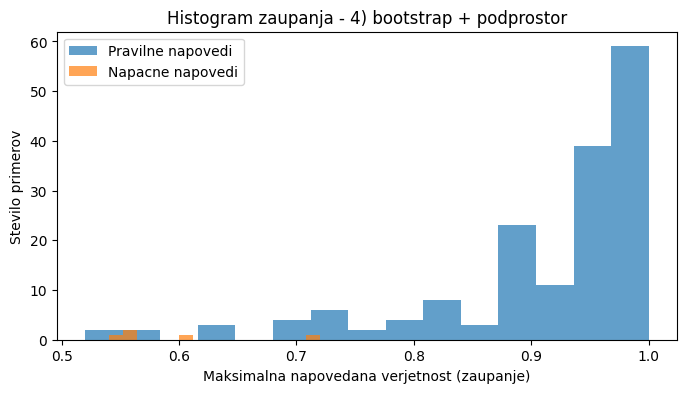

=== 4) bootstrap + podprostor ===
Tocnost (ucna): 1.0000
Tocnost (testna): 0.9708
AUC (ucna): 1.0000
AUC (testna): 0.9980
Povprecna Pearsonova korelacija med drevesi (test): 0.6826


In [23]:
# Konfiguracija 4: VrecaModelov (bootstrap=True, max_features=int(sqrt(30)))
np.random.seed(42)
model_cfg4 = VrecaModelov(
    n_estimators=50,
    bootstrap=True,
    max_features=n_feat_sqrt
)
model_cfg4.fit(X_w_train, y_w_train)
_eval_in_histogram(model_cfg4, "4) bootstrap + podprostor")

##### 2.d – Odgovori

**1) Katera konfiguracija je najboljša in zakaj?**

Najboljša je **konfiguracija 4 (bootstrap + podprostor)**.

- Točnost (test): **0.9708** (najvišja med vsemi)
- AUC (test): **0.9980** (najvišji med vsemi)

Primerjava:
- Konfiguracija 1 (eno drevo): točnost 0.9415, AUC 0.9438
- Konfiguracija 2 (samo bootstrap): točnost 0.9591, AUC 0.9929
- Konfiguracija 3 (samo podprostor): točnost 0.9591, AUC 0.9967
- Konfiguracija 4 (bootstrap + podprostor): točnost 0.9708, AUC 0.9980

**2) Kako korelacija dreves vpliva na kakovost ansambla?**

Nižja korelacija med drevesi praviloma izboljša ansambel, ker drevesa delajo različne napake in se te pri glasovanju bolje izničijo.

Iz rezultatov:
- Konfiguracija 2: povp. korelacija **0.8131**
- Konfiguracija 3: povp. korelacija **0.7352**
- Konfiguracija 4: povp. korelacija **0.6826** (najnižja) in hkrati najboljši testni rezultat

Torej manj kot se drevesa podobna, večja je korist ansambliranja.

**3) Kaj histogram zaupanja pove o tem, kdaj model naredi napako?**

Histogrami kažejo:
- pravilne napovedi so večinoma pri višjem zaupanju (bližje 1),
- napačne napovedi so pogosteje pri nižjem/srednjem zaupanju,
- pri boljših konfiguracijah (zlasti 4) je manj napačnih napovedi in te so bolj skoncentrirane pri nižjem zaupanju.

Kadar model vrne nižjo maksimalno verjetnost, je tveganje napake večje. To je uporabno za označevanje negotovih primerov za dodatno preverjanje.

##### 2.e: Napovedna moč spremenljivk

Iz konfiguracije bootstrap + podprostor (100 dreves) izračunaj povprečno napovedno moč vsake od 30 napovednih spremenljivk čez vsa drevesa ansambla in jo vizualiziraj s stolpčnim diagramom.

Odgovori: katere 3 napovedne spremenljivke so najpomembnejše (imajo največjo napovedno moč)?

## Naloga 3: Klasifikacija oblačil s slikovnimi podatki

Analiziraj podatke iz podatkovne množice **Fashion-MNIST** in sestavi napovedni model, ki bo čim boljše klasificiral slike oblačil v 10 razredov. Poskrbi, da poleg ocene zmogljivosti modela poročaš tudi o **stabilnosti ocene**. Opiši tvoj izbrani model ter kako in zakaj si se odločal/a pri vsakem vidiku njegove zasnove (arhitektura, hiperparametri, regularizacija). Opiši tudi modele in arhitekture, ki si jih poskusil/a, a jih nisi izbral/a, ker niso dosegali zmogljivosti izbranega modela.

Zgraditi moraš nevronsko mrežo s knjižnico PyTorch in jo primerjati z vsaj enim ne-nevronskim modelom (npr. naključni gozd ali SVM). Kot mero zmogljivosti lahko uporabiš poljubno mero za večrazredno klasifikacijo, ki smo jo obravnavali na predavanjih in/ali vajah. Obrazloži svojo izbiro mere zmogljivosti.

**Podatkovna množica** vsebuje slike oblačil velikosti 28x28 točk (za vsako točko je na voljo intenziteta sive barve) iz 10 razredov: Majica, Hlače, Pulover, Obleka, Plašč, Sandal, Srajca, Superga, Torba, Škorenj. Za hitrejše treniranje na prenosnikih bomo uporabili spodaj vzorčeno razdelitev na učne in testne podatke: 10.000 učnih in 2.000 testnih primerov (naključno izbranih).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

RAZREDI = ['Majica', 'Hlače', 'Pulover', 'Obleka', 'Plašč', 'Sandal', 'Srajca', 'Superga', 'Torba', 'Škorenj']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_polni = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_polni  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

np.random.seed(42)
train_idx_nn = np.random.choice(len(train_polni), 10000, replace=False)
test_idx_nn  = np.random.choice(len(test_polni),   2000, replace=False)

train_set = Subset(train_polni, train_idx_nn.tolist())
test_set  = Subset(test_polni,  test_idx_nn.tolist())

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)